# Matplotlib analysis process

## Step 1
- Import the appropriate modules.
- Connect to our data set.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

column_names = ['ID-Date', 'Time', 'RecordID', 'Status', 'Latitude', 'Longitude', 'Windspeed', 'Pressure', 'Extra1', 'Extra2', 'Extra3', 'Extra4', 'Extra5',
                'Extra6', 'Extra7', 'Extra8', 'Extra9', 'Extra10', 'Extra11', 'Extra12']

# Use my list of data to update the column names
df = pd.read_csv('http://128.198.162.191/dataFiles/HURRICANES/hurdat2-1851-2023-051124.txt', names=column_names, usecols=range(len(column_names)), on_bad_lines='skip')


df.head()

,ID-Date,Time,RecordID,Status,Latitude,Longitude,Windspeed,Pressure,Extra1,Extra2,Extra3,Extra4,Extra5,Extra6,Extra7,Extra8,Extra9,Extra10,Extra11,Extra12
0,AL011851,UNNAMED,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18510625,0000,,HU,28.0N,94.8W,80.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
2,18510625,0600,,HU,28.0N,95.4W,80.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
3,18510625,1200,,HU,28.0N,96.0W,80.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
4,18510625,1800,,HU,28.1N,96.5W,80.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0


## Step 2
- Use Pandas to shape our dataframes into the answers for whatever business question we're trying to answer.

For example: "How many Hurricanes by category are there for each year?"

### Cleaning data
Sometimes the data we're working with is less than perfect and we have to take steps to "clean" the data to work with it appropriately.

In [4]:
# Extract ID, Year and Month from the data
df['YEAR'] = ''
df['MONTH'] =''

# Only extract the year and onth where ID-Date is not blank and has "AL" as an identifier
df.loc[~df['ID-Date'].str.contains('AL'), 'YEAR'] = df['ID-Date'].str[:4]
df.loc[~df['ID-Date'].str.contains('AL'), 'MONTH'] = df['ID-Date'].str[4:6]

# Create a UNIQUE ID column that copies the AL identifier
df["UNIQUE_ID"] = df["ID-Date"].apply(lambda x: x if "AL" in x else None)

# Forward fill the UNIQUE-ID
df['UNIQUE_ID'] = df['UNIQUE_ID'].ffill()

df.head()

,ID-Date,Time,RecordID,Status,Latitude,Longitude,Windspeed,Pressure,Extra1,Extra2,...,Extra7,Extra8,Extra9,Extra10,Extra11,Extra12,CATEGORY,YEAR,MONTH,UNIQUE_ID
0,AL011851,UNNAMED,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,,AL011851
1,18510625,0000,,HU,28.0N,94.8W,80.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,Category 1,1851,06,AL011851
2,18510625,0600,,HU,28.0N,95.4W,80.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,Category 1,1851,06,AL011851
3,18510625,1200,,HU,28.0N,96.0W,80.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,Category 1,1851,06,AL011851
4,18510625,1800,,HU,28.1N,96.5W,80.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,Category 1,1851,06,AL011851


In [5]:
# Count hurricanes by year
hurricanes_by_yr = df.groupby('YEAR')['UNIQUE_ID'].count().reset_index(name='COUNT')

hurricanes_by_yr

,YEAR,COUNT
0,,1973
1,1851,98
2,1852,134
3,1853,100
4,1854,60
...,...,...
169,2019,493
170,2020,883
171,2021,602
172,2022,471


In [6]:
df['YEAR'] = pd.to_numeric(df['YEAR'], errors='coerce')

# Drop any rows where YEAR is NaN
df_clean = df.dropna(subset=['YEAR'])

# Convert YEAR to an Integer
df_clean.loc[:,'YEAR'] = df_clean['YEAR'].astype(int)

# Now we'll group cleaned data
hurricanes_by_year = df_clean.groupby('YEAR')['UNIQUE_ID'].nunique()

## Step 3 - Visualize the results
Now that we have the data shaped to answer our question, we can turn our attention to how to visualize the data to present it.

<function matplotlib.pyplot.show(close=None, block=None)>

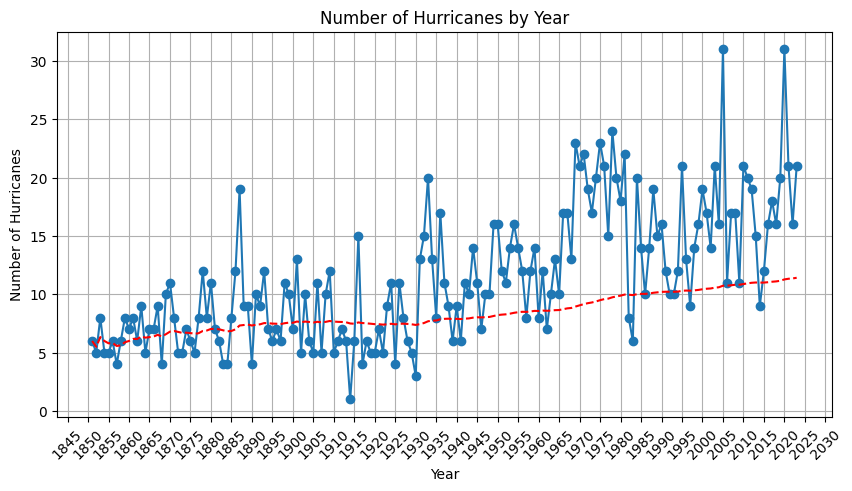

In [8]:
# Plot the results
plt.figure(figsize=(10,5))
plt.plot (hurricanes_by_year.index, hurricanes_by_year.values, marker='o')
plt.xlabel("Year")
plt.ylabel("Number of Hurricanes")
plt.title("Number of Hurricanes by Year")

plt.gca().xaxis.set_major_locator(plt.MultipleLocator(5))
plt.xticks(rotation=45)

#Calculate a cumulative average
cumulative_avg_hurricanes = hurricanes_by_year.expanding().mean()
plt.plot(cumulative_avg_hurricanes.index, cumulative_avg_hurricanes.values, color='red', linestyle='--', label='Cumulative Average')

plt.grid(True)
plt.show

# Functions
Python functions allow us to create “sub-routines” that contain logic that we can use repeatedly throughout our code. Functions provide a level of modularity to Python code and provide the ability for Python to be an object oriented type of language.

In [9]:
def categorize_wind_speed(speed):
    if 74 <= speed <= 95:
        return "Category 1"
    elif 96 <= speed <=110:
        return "Category 2"
    elif 111 <= speed <= 129:
        return "Category 3"
    elif 130 <= speed <= 156:
        return "Category 4"
    elif speed >= 157:
        return "Category 5"
    

df['CATEGORY'] = df['Windspeed'].apply(categorize_wind_speed)

hurricanes_by_year_category = df.groupby(['YEAR', 'CATEGORY'])['UNIQUE_ID'].count().unstack(fill_value=0)

hurricanes_by_year_category

CATEGORY,Category 1,Category 2,Category 3,Category 4,Category 5
YEAR,,,,,
1851.0,16,5,0,0,0
1852.0,51,10,0,0,0
1853.0,20,21,13,3,0
1854.0,14,9,0,0,0
1855.0,9,5,0,0,0
...,...,...,...,...,...
2019.0,51,19,10,11,2
2020.0,79,18,11,7,0
2021.0,32,24,19,10,0


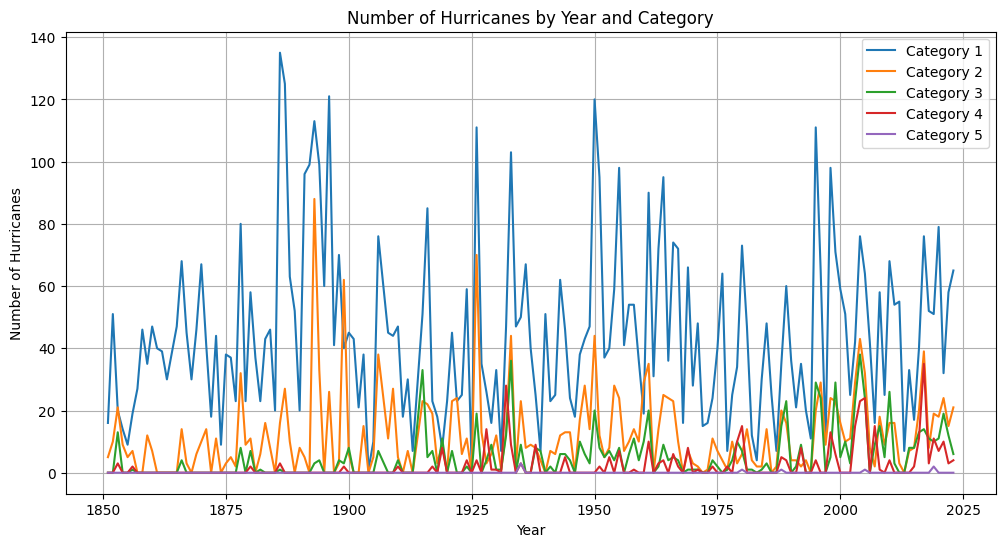

In [10]:
# Visualize our data
plt.figure(figsize=(12,6))

for category in hurricanes_by_year_category.columns:
    plt.plot(hurricanes_by_year_category.index, hurricanes_by_year_category[category], label=category)

plt.xlabel("Year")
plt.ylabel("Number of Hurricanes")
plt.title("Number of Hurricanes by Year and Category")
plt.grid()
plt.legend()

plt.show()